# 🧪 A/B Testing — Recommendation System

## Project Objective

This project evaluates whether an improved recommendation system increased conversion among new users of an international online store.

According to the experiment specification, the test was expected to:

- run from **7 December 2020 to 1 January 2021**;
- stop accepting new participants after **21 December 2020**;
- include approximately **6,000 participants**;
- include **15% of new users from the EU region**;
- compare **Group A (control)** with **Group B (test)**;
- evaluate `product_page`, `product_cart`, and `purchase` events within **14 days of registration**;
- produce at least a **10% relative increase** in each main funnel stage for Group B.

### Hypotheses

For each main funnel event:

- **H₀:** the proportion of users reaching the event is the same in Groups A and B.
- **H₁:** the proportion of users reaching the event differs between Groups A and B.

I use a **two-proportion Z-test** because the analysis compares conversion proportions between two independent groups.

Statistical significance alone is not enough to consider the experiment successful. Group B must also achieve the expected business effect: **at least +10% relative improvement across all main stages**.


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import norm

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

## 1. Data Loading

To make the notebook portable across different environments, the helper function below looks for each CSV file in the course dataset directory, the current working directory, and `/mnt/data/`.


In [44]:
def load_csv(*filenames):
    candidates = []

    for filename in filenames:
        candidates.extend([
            Path('/datasets') / filename,
            Path.cwd() / filename,
            Path('/mnt/data') / filename
        ])

    for path in candidates:
        if path.exists():
            print(f'Loaded file: {path}')
            return pd.read_csv(path)

    raise FileNotFoundError(
        'None of the expected files were found. Check whether the CSV files '
        'are in the notebook directory or in /datasets/.'
    )

marketing = load_csv(
    'ab_project_marketing_events_us.csv',
    'ab_project_marketing_events_us_(1).csv'
)

users = load_csv(
    'final_ab_new_users_upd_us.csv',
    'final_ab_new_users_upd_us_(1).csv'
)

events = load_csv(
    'final_ab_events_upd_us.csv'
)

participants = load_csv(
    'final_ab_participants_upd_us.csv',
    'final_ab_participants_upd_us_(1).csv'
)

Loaded file: /datasets/ab_project_marketing_events_us.csv
Loaded file: /datasets/final_ab_new_users_upd_us.csv
Loaded file: /datasets/final_ab_events_upd_us.csv
Loaded file: /datasets/final_ab_participants_upd_us.csv


## 2. Initial Data Quality Review

I begin by checking:

- dataset dimensions;
- data types;
- missing values;
- duplicate rows;
- key categories;
- date ranges.

The goal is to understand the quality of the source data before evaluating the experiment.


In [45]:
datasets = {
    'marketing': marketing,
    'users': users,
    'events': events,
    'participants': participants
}

for name, df in datasets.items():
    print('\n' + '=' * 70)
    print(name.upper())
    print('=' * 70)
    print('Shape:', df.shape)
    print('\nData types:')
    print(df.dtypes)
    print('\nMissing values:')
    print(df.isna().sum())
    print('\nFully duplicated rows:', df.duplicated().sum())
    print('\nFirst rows:')
    display(df.head())


MARKETING
Shape: (14, 4)

Data types:
name         object
regions      object
start_dt     object
finish_dt    object
dtype: object

Missing values:
name         0
regions      0
start_dt     0
finish_dt    0
dtype: int64

Fully duplicated rows: 0

First rows:


,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11



USERS
Shape: (58703, 4)

Data types:
user_id       object
first_date    object
region        object
device        object
dtype: object

Missing values:
user_id       0
first_date    0
region        0
device        0
dtype: int64

Fully duplicated rows: 0

First rows:


,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone



EVENTS
Shape: (423761, 4)

Data types:
user_id        object
event_dt       object
event_name     object
details       float64
dtype: object

Missing values:
user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64

Fully duplicated rows: 0

First rows:


,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.9900
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.9900
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.9900
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.9900
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.9900



PARTICIPANTS
Shape: (14525, 3)

Data types:
user_id    object
group      object
ab_test    object
dtype: object

Missing values:
user_id    0
group      0
ab_test    0
dtype: int64

Fully duplicated rows: 0

First rows:


,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


### Initial Diagnostic

The four datasets contain no fully duplicated rows.

Missing values appear only in the `details` column of the events dataset. Rather than filling or removing them immediately, I investigate whether the missingness is related to specific event types.


In [46]:
print(pd.crosstab(events['event_name'], events['details'].notna()))

display(
    events.groupby('event_name')['details']
    .agg(['count', 'min', 'max'])
)

details        False  True 
event_name                 
login         182465      0
product_cart   60120      0
product_page  120862      0
purchase           0  60314


,count,min,max
event_name,,,
login,0,NaN,NaN
product_cart,0,NaN,NaN
product_page,0,NaN,NaN
purchase,60314,4.9900,499.9900


The missing values in `details` are **structural**: the field is populated for `purchase` events and absent for the other event types.

For that reason, filling the missing values or removing those rows would distort the data and is not appropriate for this analysis.


In [47]:
users['first_date'] = pd.to_datetime(users['first_date'])

events['event_dt'] = pd.to_datetime(events['event_dt'])

marketing['start_dt'] = pd.to_datetime(marketing['start_dt'])
marketing['finish_dt'] = pd.to_datetime(marketing['finish_dt'])

print('Registrations:', users['first_date'].min(), 'to', users['first_date'].max())
print('Events:', events['event_dt'].min(), 'to', events['event_dt'].max())
print('\nAvailable event types:')
print(events['event_name'].value_counts())

Registrations: 2020-12-07 00:00:00 até 2020-12-23 00:00:00
Eventos: 2020-12-07 00:00:33 até 2020-12-30 23:36:33

Available event types:
login           182465
product_page    120862
purchase         60314
product_cart     60120
Name: event_name, dtype: int64


## 3. Experimental Design Validation

Before comparing conversion rates, I verify whether the experiment was executed according to its technical specification.

I check:

1. the number of participants in `recommender_system_test`;
2. group allocation;
3. participant regions and registration dates;
4. whether users appear in both A and B;
5. overlap with other experiments;
6. observed participation among eligible EU users.


In [48]:
target_test = participants[
    participants['ab_test'] == 'recommender_system_test'
].copy()

print('Participants in recommender_system_test:', len(target_test))
print('\nGroup distribution:')
print(target_test['group'].value_counts())

target_users = target_test.merge(
    users,
    on='user_id',
    how='left',
    validate='many_to_one'
)

print('\nRegions:')
print(target_users['region'].value_counts())

print(
    '\nRegistration dates:',
    target_users['first_date'].min(),
    'to',
    target_users['first_date'].max()
)

Participants in recommender_system_test: 3675

Group distribution:
A    2747
B     928
Name: group, dtype: int64

Regions:
EU           3481
N.America     119
APAC           45
CIS            30
Name: region, dtype: int64

Registration dates: 2020-12-07 00:00:00 até 2020-12-21 00:00:00


In [49]:
# Users assigned to more than one group within recommender_system_test
groups_per_user = (
    target_test.groupby('user_id')['group']
    .nunique()
)

users_in_A_and_B = groups_per_user[groups_per_user > 1]

print(
    'Users simultaneously assigned to A and B:',
    len(users_in_A_and_B)
)

# Target-test users who also participate in another experiment
other_test_ids = set(
    participants.loc[
        participants['ab_test'] != 'recommender_system_test',
        'user_id'
    ]
)

target_users['in_other_test'] = target_users['user_id'].isin(other_test_ids)

print(
    'Target-test participants also present in another experiment:',
    target_users['in_other_test'].sum()
)

Users simultaneously assigned to A and B: 0
Target-test participants also present in another experiment: 887


In [50]:
# Eligible population according to the experiment specification
eu_new_users = users[
    (users['region'] == 'EU') &
    (users['first_date'].between('2020-12-07', '2020-12-21'))
].copy()

# Eligible target-test participants before removing overlap with another experiment
eligible_target = target_users[
    (target_users['region'] == 'EU') &
    (target_users['first_date'].between('2020-12-07', '2020-12-21'))
].copy()

participation_rate = (
    eligible_target['user_id'].nunique() /
    eu_new_users['user_id'].nunique()
)

print('Eligible new EU users:', eu_new_users['user_id'].nunique())
print('Eligible test participants:', eligible_target['user_id'].nunique())
print(f'Observed participation rate: {participation_rate:.2%}')
print('Planned participation rate: 15.00%')

Eligible new EU users: 39466
Eligible test participants: 3481
Observed participation rate: 8.82%
Planned participation rate: 15.00%


### Experimental Design Assessment

The experiment specification expected approximately **6,000 participants**, but the data contains **3,675 users** in `recommender_system_test`.

Of these participants:

- **3,481** are from the EU region;
- **887** also participated in another experiment;
- no users appear simultaneously in both A and B within the target test;
- observed participation among eligible new EU users is **8.82%**, below the planned **15%**.

These differences mean the experiment was not executed exactly as designed and should be interpreted with caution.


## 4. Building the Analytical Sample

For the main analysis, I keep only users who:

- belong to `recommender_system_test`;
- are from the EU region;
- registered between 7 and 21 December 2020;
- are not participating in another experiment.

This creates a cleaner sample for comparing Groups A and B.


In [51]:
test_users = eligible_target[
    ~eligible_target['in_other_test']
].copy()

group_sizes = (
    test_users.groupby('group')['user_id']
    .nunique()
)

print('Final analytical sample:', test_users['user_id'].nunique())
print('\nUsers by group:')
print(group_sizes)

print('\nRelative group allocation:')
print((group_sizes / group_sizes.sum()).map(lambda x: f'{x:.2%}'))

print('\nDevice distribution:')
display(
    pd.crosstab(
        test_users['group'],
        test_users['device'],
        normalize='index'
    ).round(4)
)

Final analytical sample: 2594

Users by group:
group
A    1939
B     655
Name: user_id, dtype: int64

Relative group allocation:
group
A    74.75%
B    25.25%
Name: user_id, dtype: object

Device distribution:


device,Android,Mac,PC,iPhone
group,,,,
A,0.4425,0.0913,0.2599,0.2063
B,0.4718,0.0885,0.2412,0.1985


The final analytical sample contains **2,594 users**:

- **1,939 in Group A**
- **655 in Group B**

This corresponds to an allocation of approximately **75% / 25%**, which is considerably less balanced than a 50/50 split and reduces statistical efficiency for Group B.

Device distribution is broadly similar across the two groups, which is reassuring when comparing user behaviour.


## 5. Marketing Campaigns During the Experiment

Promotional campaigns running at the same time as an A/B test can influence user behaviour and become an external source of variation.

I therefore check whether any marketing campaigns overlap with the experiment period.


In [52]:
test_start = pd.Timestamp('2020-12-07')
test_end = pd.Timestamp('2021-01-01')

marketing_overlap = marketing[
    (marketing['start_dt'] <= test_end) &
    (marketing['finish_dt'] >= test_start)
].copy()

display(marketing_overlap)

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
10,CIS New Year Gift Lottery,CIS,2020-12-30,2021-01-07


The **Christmas & New Year Promo** starts on **25 December 2020** and includes the EU region.

This means that part of the experiment overlaps with a major seasonal promotion. Randomisation may reduce some of this influence across groups, but the campaign remains an important contextual limitation when interpreting the results.


## 6. Event Preparation and the 14-Day Observation Window

The experiment specification states that the expected effect should occur within 14 days after registration.

To respect this requirement, I calculate the number of days between registration and each event and keep only events occurring from day 0 through day 14.


In [53]:
test_events = events.merge(
    test_users[['user_id', 'group', 'first_date']],
    on='user_id',
    how='inner',
    validate='many_to_one'
)

test_events['days_since_signup'] = (
    (test_events['event_dt'] - test_events['first_date'])
    .dt.total_seconds() / 86400
)

print('Events before the 14-day filter:', len(test_events))
print('Events before registration:', (test_events['days_since_signup'] < 0).sum())
print('Events after 14 days:', (test_events['days_since_signup'] > 14).sum())

test_events_14d = test_events[
    (test_events['days_since_signup'] >= 0) &
    (test_events['days_since_signup'] <= 14)
].copy()

print('Events kept within the 14-day window:', len(test_events_14d))
print('Users with at least one event:', test_events_14d['user_id'].nunique())

Events before the 14-day filter: 16959
Events before registration: 0
Events after 14 days: 544
Events kept within the 14-day window: 16415
Users with at least one event: 2594


All **2,594 users** in the final analytical sample have at least one event within the available observation window.

There are events occurring more than 14 days after registration, so applying the individual time-window filter is necessary to keep the analysis aligned with the experiment specification.


## 7. Event Coverage Over Time

In addition to each user's 14-day window, I check whether the source data provides complete event coverage through the planned end of the experiment.


,event_date,events
0,2020-12-07,11385
1,2020-12-08,12547
2,2020-12-09,12122
3,2020-12-10,14077
4,2020-12-11,13864
5,2020-12-12,17634
6,2020-12-13,20985
7,2020-12-14,26184
8,2020-12-15,23469
9,2020-12-16,20909


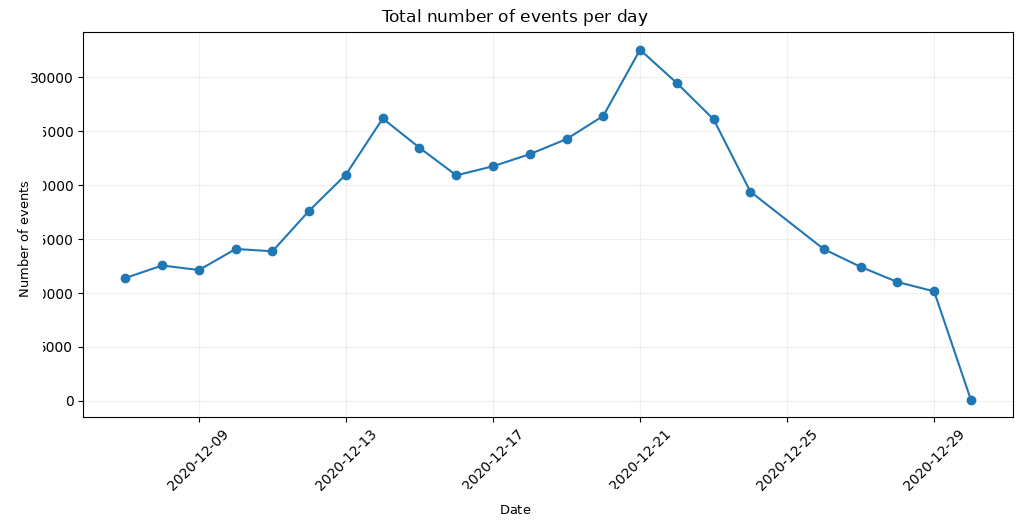

In [54]:
events['event_date'] = events['event_dt'].dt.date

daily_all_events = (
    events.groupby('event_date')
    .size()
    .rename('events')
    .reset_index()
)

display(daily_all_events)

plt.figure(figsize=(12, 5))
plt.plot(
    pd.to_datetime(daily_all_events['event_date']),
    daily_all_events['events'],
    marker='o'
)
plt.title('Total number of events per day')
plt.xlabel('Date')
plt.ylabel('Number of events')
plt.xticks(rotation=45)
plt.grid(alpha=0.2)
plt.show()

### Temporal Coverage Issue

The experiment specification states that events should be available through **1 January 2021**, but the dataset ends on **30 December 2020**.

There are also clear collection issues:

- no events are recorded on **25 December**;
- only **89 events** are recorded on **30 December**;
- event volume drops sharply at the end of the dataset.

As a result, users who registered later in the experiment do not have a complete and reliable 14-day observation window. This is an important limitation for causal interpretation.


## 8. Number of Events per User

Because the groups are different sizes, I compare the distribution of events **per user** rather than relying on raw event totals.


,users,mean,median,std,min,q1,q3,max
group,,,,,,,,
A,1939,6.6700,6,3.6800,1,4,9,24
B,655,5.3200,4,3.2400,1,3,6,24


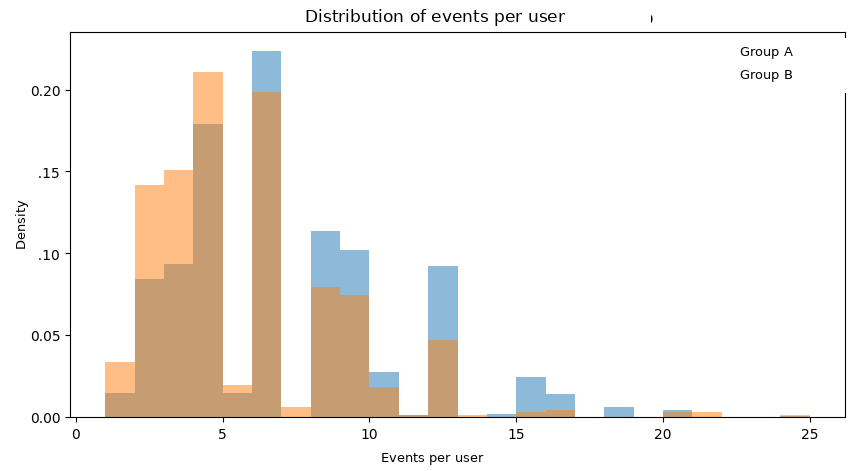

In [55]:
events_per_user = (
    test_events_14d
    .groupby(['group', 'user_id'])
    .size()
    .reset_index(name='events_count')
)

summary_events_user = (
    events_per_user.groupby('group')['events_count']
    .agg(
        users='count',
        mean='mean',
        median='median',
        std='std',
        min='min',
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        max='max'
    )
)

display(summary_events_user.round(2))

plt.figure(figsize=(10, 5))

for group in ['A', 'B']:
    subset = events_per_user.loc[
        events_per_user['group'] == group,
        'events_count'
    ]
    plt.hist(
        subset,
        bins=range(1, int(events_per_user['events_count'].max()) + 2),
        alpha=0.5,
        label=f'Group {group}',
        density=True
    )

plt.title('Distribution of events per user')
plt.xlabel('Events per user')
plt.ylabel('Density')
plt.legend()
plt.show()

User activity is not distributed equally across the groups.

- **Group A:** approximately **6.67 events per user** on average, with a median of **6**.
- **Group B:** approximately **5.32 events per user** on average, with a median of **4**.

Group B therefore shows lower overall engagement in the available data.


## 9. Daily Event Distribution

To compare groups of different sizes, I normalise daily event counts by the total number of participants in each group.


group,A,B
event_date,,
2020-12-07,0.1140,0.4090
2020-12-08,0.1230,0.2580
2020-12-09,0.1450,0.3820
2020-12-10,0.1270,0.2780
2020-12-11,0.1360,0.1760
2020-12-12,0.1410,0.2290
2020-12-13,0.1200,0.1570
2020-12-14,0.3890,0.2950
2020-12-15,0.4020,0.2500


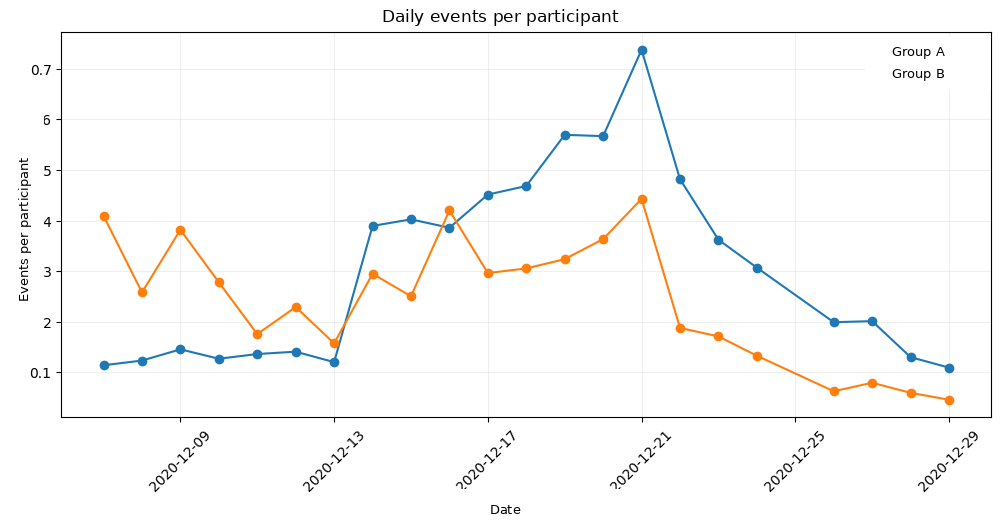

In [56]:
test_events_14d['event_date'] = test_events_14d['event_dt'].dt.date

daily_group_events = (
    test_events_14d
    .groupby(['event_date', 'group'])
    .size()
    .unstack(fill_value=0)
)

daily_events_per_user = daily_group_events.div(group_sizes, axis=1)

display(daily_events_per_user.round(3))

plt.figure(figsize=(12, 5))

for group in ['A', 'B']:
    plt.plot(
        pd.to_datetime(daily_events_per_user.index),
        daily_events_per_user[group],
        marker='o',
        label=f'Group {group}'
    )

plt.title('Daily events per participant')
plt.xlabel('Date')
plt.ylabel('Events per participant')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

The daily event pattern differs between the groups and also reflects the data-quality issues identified earlier.

There is a strong decline after 21 December, no event data on 25 December, and unusually low coverage at the end of the file.

I also review registration dates by group to understand whether differences in cohort timing could contribute to the observed behaviour.


group,A,B
first_date,,
2020-12-07,0.0562,0.1908
2020-12-08,0.0335,0.0473
2020-12-09,0.0289,0.0824
2020-12-10,0.0232,0.0427
2020-12-11,0.0356,0.0198
2020-12-12,0.0227,0.0580
2020-12-13,0.0206,0.0168
2020-12-14,0.1398,0.0840
2020-12-15,0.0748,0.0336


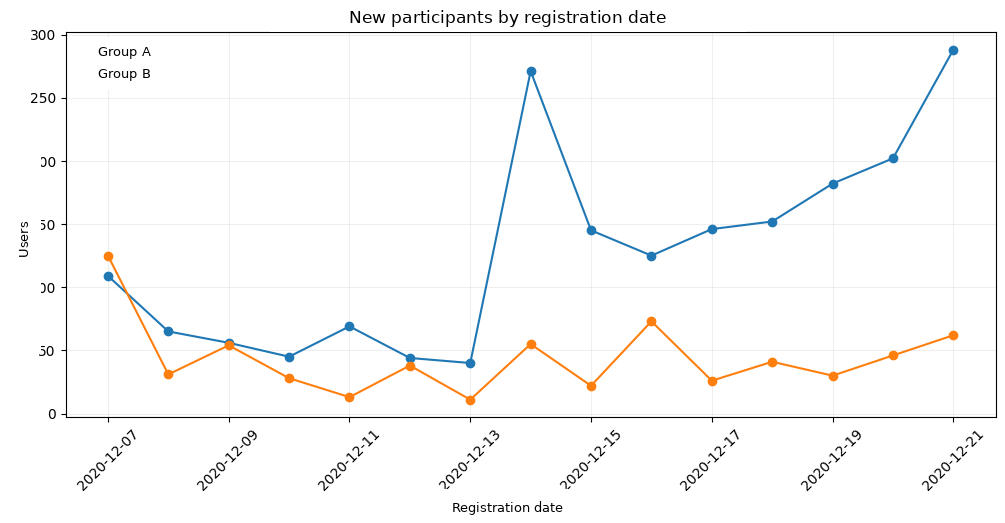

In [57]:
registration_distribution = pd.crosstab(
    test_users['first_date'],
    test_users['group'],
    normalize='columns'
)

display(registration_distribution.round(4))

registration_counts = pd.crosstab(
    test_users['first_date'],
    test_users['group']
)

plt.figure(figsize=(12, 5))

for group in ['A', 'B']:
    plt.plot(
        registration_counts.index,
        registration_counts[group],
        marker='o',
        label=f'Group {group}'
    )

plt.title('New participants by registration date')
plt.xlabel('Registration date')
plt.ylabel('Users')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 10. Conversion Funnel

For each group, I calculate the proportion of participants who reached each event at least once within 14 days.

The main business stages are:

`product_page` → `product_cart` → `purchase`

I measure each event relative to the full group size because the experiment goal is to compare the share of users who reach each key action.


In [58]:
event_order = ['login', 'product_page', 'product_cart', 'purchase']

funnel_counts = (
    test_events_14d
    .groupby(['group', 'event_name'])['user_id']
    .nunique()
    .unstack(fill_value=0)
)

funnel_rates = (
    funnel_counts[event_order]
    .div(group_sizes, axis=0)
)

print('Unique users by event:')
display(funnel_counts[event_order])

print('Conversion relative to total group size:')
display((funnel_rates * 100).round(2))

Unique users by event:


event_name,login,product_page,product_cart,purchase
group,,,,
A,1939,1265,589,613
B,654,367,184,191


Conversion relative to total group size:


event_name,login,product_page,product_cart,purchase
group,,,,
A,100.0000,65.2400,30.3800,31.6100
B,99.8500,56.0300,28.0900,29.1600


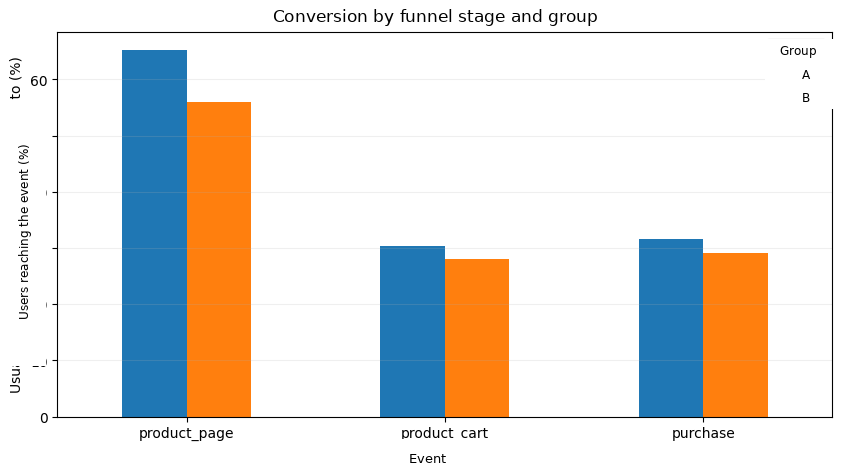

In [59]:
funnel_plot = (
    funnel_rates[['product_page', 'product_cart', 'purchase']]
    .T * 100
)

ax = funnel_plot.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Conversion by funnel stage and group')
plt.xlabel('Event')
plt.ylabel('Users reaching the event (%)')
plt.xticks(rotation=0)
plt.legend(title='Group')
plt.grid(axis='y', alpha=0.2)
plt.show()

In [60]:
comparison = pd.DataFrame(index=['product_page', 'product_cart', 'purchase'])

comparison['A_conversion'] = funnel_rates.loc[
    'A', comparison.index
]

comparison['B_conversion'] = funnel_rates.loc[
    'B', comparison.index
]

comparison['difference_pp'] = (
    comparison['B_conversion'] - comparison['A_conversion']
) * 100

comparison['relative_lift_B_vs_A'] = (
    comparison['B_conversion'] / comparison['A_conversion'] - 1
) * 100

display(
    comparison.assign(
        A_conversion=comparison['A_conversion'] * 100,
        B_conversion=comparison['B_conversion'] * 100
    ).round(2)
)

,A_conversion,B_conversion,difference_pp,relative_lift_B_vs_A
product_page,65.2400,56.0300,-9.2100,-14.1200
product_cart,30.3800,28.0900,-2.2800,-7.5200
purchase,31.6100,29.1600,-2.4500,-7.7600


### Funnel Interpretation

Observed conversion rates are:

- `product_page`: **65.24% in A** vs **56.03% in B** — approximately **-14.12% relative lift**.
- `product_cart`: **30.38% in A** vs **28.09% in B** — approximately **-7.52% relative lift**.
- `purchase`: **31.61% in A** vs **29.16% in B** — approximately **-7.76% relative lift**.

Group B does not achieve the required +10% improvement in any of the three main stages. In the observed data, all three conversion rates are below Group A.


## 11. Two-Proportion Z-Tests

For each main event, I apply a two-sided Z-test for two independent proportions.

### Why this test?

For each event, every user can be classified as either:

- having reached the event at least once; or
- not having reached the event.

The analysis therefore compares two proportions between independent groups.

I use:

- **α = 0.05** as the standard significance level;
- a **Bonferroni-adjusted α ≈ 0.0167** because three related hypothesis tests are performed.


In [61]:
def z_test_two_proportions(success_a, n_a, success_b, n_b):
    p_a = success_a / n_a
    p_b = success_b / n_b

    pooled = (success_a + success_b) / (n_a + n_b)

    se = np.sqrt(
        pooled * (1 - pooled) *
        (1 / n_a + 1 / n_b)
    )

    z = (p_b - p_a) / se
    p_value = 2 * (1 - norm.cdf(abs(z)))

    return z, p_value

alpha = 0.05
alpha_bonferroni = alpha / 3

results = []

for event in ['product_page', 'product_cart', 'purchase']:
    success_a = funnel_counts.loc['A', event]
    success_b = funnel_counts.loc['B', event]
    n_a = group_sizes['A']
    n_b = group_sizes['B']

    z, p_value = z_test_two_proportions(
        success_a, n_a,
        success_b, n_b
    )

    p_a = success_a / n_a
    p_b = success_b / n_b

    results.append({
        'event': event,
        'A_users': success_a,
        'A_total': n_a,
        'A_conversion': p_a,
        'B_users': success_b,
        'B_total': n_b,
        'B_conversion': p_b,
        'difference_pp': (p_b - p_a) * 100,
        'relative_lift_%': (p_b / p_a - 1) * 100,
        'z_stat': z,
        'p_value': p_value,
        'significant_0.05': p_value < alpha,
        'significant_bonferroni': p_value < alpha_bonferroni
    })

z_results = pd.DataFrame(results)

display(
    z_results.assign(
        A_conversion=z_results['A_conversion'] * 100,
        B_conversion=z_results['B_conversion'] * 100
    ).round(4)
)

print(f'Standard alpha: {alpha:.4f}')
print(f'Bonferroni-adjusted alpha: {alpha_bonferroni:.4f}')

,event,A_users,A_total,A_conversion,B_users,B_total,B_conversion,difference_pp,relative_lift_%,z_stat,p_value,significant_0.05,significant_bonferroni
0,product_page,1265,1939,65.2398,367,655,56.0305,-9.2093,-14.1160,-4.2186,0.0000,True,True
1,product_cart,589,1939,30.3765,184,655,28.0916,-2.2849,-7.5219,-1.1054,0.2690,False,False
2,purchase,613,1939,31.6142,191,655,29.1603,-2.4539,-7.7621,-1.1741,0.2404,False,False


Standard alpha: 0.0500
Bonferroni-adjusted alpha: 0.0167


### Statistical Interpretation

#### `product_page`

The p-value is approximately **0.000025**, below both 0.05 and the Bonferroni-adjusted threshold.

I therefore reject H₀ for `product_page`: there is statistical evidence of a difference between the groups.

However, the difference is **unfavourable to Group B**. Conversion decreases by approximately **9.21 percentage points**, equivalent to a relative decline of about **14.12%**.

#### `product_cart`

The p-value is approximately **0.269**. There is not enough statistical evidence to conclude that the two proportions differ.

The observed rate in Group B is still lower than in Group A and does not approach the expected +10% improvement.

#### `purchase`

The p-value is approximately **0.240**. Again, there is not enough statistical evidence to conclude that the groups differ.

The observed conversion in Group B is lower and does not meet the business target.

### Experiment Decision

The test does **not demonstrate success for the new recommendation system**.

The only statistically clear difference occurs at `product_page`, but in the opposite direction from the expected effect. The remaining stages show no statistically demonstrated improvement and also have negative observed effects.


## 12. Robustness Check — Cohorts with More Complete Observation

Because the event dataset has missing or incomplete coverage near the end of December, I perform a robustness check using users who registered early enough to have a more complete observable window before the data-quality failure.

This does not repair the original experiment, but it helps test whether the business conclusion changes in a cleaner subset.


In [62]:
robust_users = test_users[
    test_users['first_date'] <= '2020-12-10'
].copy()

robust_sizes = (
    robust_users.groupby('group')['user_id']
    .nunique()
)

robust_events = events.merge(
    robust_users[['user_id', 'group', 'first_date']],
    on='user_id',
    how='inner'
)

robust_events['days_since_signup'] = (
    (robust_events['event_dt'] - robust_events['first_date'])
    .dt.total_seconds() / 86400
)

robust_events = robust_events[
    robust_events['days_since_signup'].between(0, 14)
].copy()

robust_counts = (
    robust_events.groupby(['group', 'event_name'])['user_id']
    .nunique()
    .unstack(fill_value=0)
)

robust_rates = robust_counts.div(robust_sizes, axis=0)

robust_comparison = pd.DataFrame(index=[
    'product_page', 'product_cart', 'purchase'
])

robust_comparison['A_conversion'] = robust_rates.loc[
    'A', robust_comparison.index
]

robust_comparison['B_conversion'] = robust_rates.loc[
    'B', robust_comparison.index
]

robust_comparison['relative_lift_B_vs_A'] = (
    robust_comparison['B_conversion'] /
    robust_comparison['A_conversion'] - 1
) * 100

display(
    robust_comparison.assign(
        A_conversion=robust_comparison['A_conversion'] * 100,
        B_conversion=robust_comparison['B_conversion'] * 100
    ).round(2)
)

print('Robustness-cohort sizes:')
print(robust_sizes)

,A_conversion,B_conversion,relative_lift_B_vs_A
product_page,62.1800,57.1400,-8.1000
product_cart,26.5500,26.8900,1.3000
purchase,28.7300,29.8300,3.8500


Robustness-cohort sizes:
group
A    275
B    238
Name: user_id, dtype: int64


In [63]:
robust_test_results = []

for event in ['product_page', 'product_cart', 'purchase']:
    success_a = robust_counts.loc['A', event]
    success_b = robust_counts.loc['B', event]
    n_a = robust_sizes['A']
    n_b = robust_sizes['B']

    z, p_value = z_test_two_proportions(
        success_a, n_a,
        success_b, n_b
    )

    p_a = success_a / n_a
    p_b = success_b / n_b

    robust_test_results.append({
        'event': event,
        'A_conversion': p_a,
        'B_conversion': p_b,
        'relative_lift_%': (p_b / p_a - 1) * 100,
        'p_value': p_value
    })

robust_z = pd.DataFrame(robust_test_results)

display(
    robust_z.assign(
        A_conversion=robust_z['A_conversion'] * 100,
        B_conversion=robust_z['B_conversion'] * 100
    ).round(4)
)

,event,A_conversion,B_conversion,relative_lift_%,p_value
0,product_page,62.1818,57.1429,-8.1036,0.2456
1,product_cart,26.5455,26.8908,1.3008,0.9298
2,purchase,28.7273,29.8319,3.8453,0.7838


### Robustness Interpretation

In the earlier-registration cohort, Group B still does not achieve the required **+10% improvement across all stages**.

The sample is much smaller, so statistical power decreases and none of the differences are statistically significant.

Even so, the business conclusion remains unchanged: there is no consistent evidence that the new recommendation system produced the expected improvement.

This robustness check also reinforces that incomplete temporal coverage is a serious limitation of the full experiment.


# Final Conclusions and Recommendations

## Experimental Quality

The experiment was not executed exactly as planned:

1. `recommender_system_test` contains **3,675 participants**, below the expected 6,000.
2. Observed participation among eligible new EU users is **8.82%**, below the planned 15%.
3. **887 participants** also appear in another experiment and were removed from the main analysis.
4. The final analytical sample is strongly unbalanced: **1,939 users in A** and **655 in B**.
5. Event coverage is incomplete: no events are recorded on 25 December, only 89 on 30 December, and the data ends before 1 January.
6. The **Christmas & New Year Promo** overlaps with part of the experiment period.

## Funnel Results

- `product_page`: **65.24% in A** vs **56.03% in B** — **-14.12% relative lift**
- `product_cart`: **30.38% in A** vs **28.09% in B** — **-7.52% relative lift**
- `purchase`: **31.61% in A** vs **29.16% in B** — **-7.76% relative lift**

The required **+10% improvement in every main stage was not achieved**.

## Statistical Results

The Z-test identifies a statistically significant difference only for `product_page` with a p-value of approximately **0.000025**.

However, this difference favours Group A rather than Group B.

For `product_cart` and `purchase`, there is not enough statistical evidence to conclude that the groups differ. The Bonferroni correction does not change the overall conclusion.

## Business Recommendation

**I do not recommend launching the new recommendation system based on this experiment.**

This decision is not based only on statistical significance. The observed effect is negative across all three main metrics, and the required +10% business improvement was not achieved.

At the same time, I would not use this experiment to conclude definitively that the new system is worse. Important issues in experiment design and data collection limit the strength of the causal conclusion.

### Recommended next steps

1. Run the experiment again without participants simultaneously enrolled in another test.
2. Reach the planned sample size and use a more balanced allocation between A and B.
3. Stop new participant enrolment early enough to guarantee a complete 14-day observation window.
4. Validate the event-data pipeline before and during the experiment.
5. Avoid major promotional periods where possible, or explicitly control for them in the experiment design and analysis.

## Overall Conclusion

With the available data, `recommender_system_test` **does not demonstrate the expected improvement**.

Group B fails to achieve +10% improvement at any of the main stages and shows a statistically significant decline at `product_page`.

The safest business decision is therefore **not to launch the change based on this test and to repeat the experiment under cleaner conditions**.

## What I Learned

What I found most valuable in this project was seeing why a good A/B test is about much more than calculating a p-value.

The quality of the experimental design, participant allocation, observation window, overlapping campaigns, and data collection all affect how confidently a business can act on the result.

This project strengthened my ability to connect statistical analysis with practical decision-making — not only asking whether a difference is significant, but whether the experiment is reliable enough to support a real product decision.


## Executive Presentation

As a complement to the full analysis, I prepared a short executive presentation summarising the main findings, experiment risks, and final recommendation.

[**View the executive presentation**](https://acrobat.adobe.com/id/urn:aaid:sc:EU:c79b274f-bd8f-4e16-930a-e8f9392ecfee)
